# 1. FaceRecognition

В этом ноутбуке мы соберём весь пайплайн вместе и проведём эксперементы с нашей системой

In [1]:
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch
from torchvision.transforms import v2
from torchvision import models
import matplotlib.pyplot as plt

import os
import pandas as pd

from PIL import Image

%matplotlib inline

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


# 2. Система распознавания лиц

## Этап 0. Подготовка

Во-первых обговорим все этапы по очереди:
1. Детекция лиц на фотографии
2. Кроп всех лиц
3. Предсказание точек лица
4. Выравнивание лиц
5. Получение эмбеддингов

Во-вторых для теста возьмём фотографию с несколькими людьми на ней, чтобы тестировать на ней нашу систему. Я взял фотографию ([ссылка](https://www.magnific.com/ru/free-photo/portrait-happy-multiracial-friends-looking-camera-standing-near-railing_4937083.htm#from_element=cross_selling__photo) с сайта [Magnefic](https://www.magnific.com/ru) по запросу "несколько людей" с пометкой "Исключить ИИ"

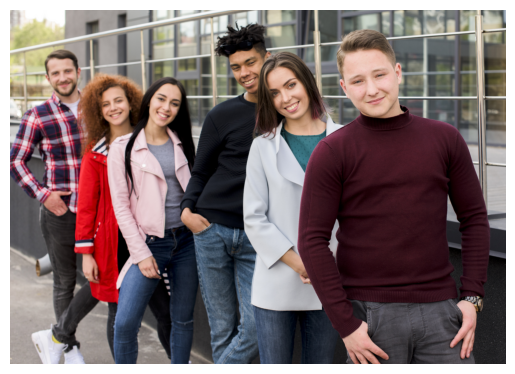

In [49]:
test_image_path = '/content/test_image.jpg'
test_image = Image.open(test_image_path)

plt.imshow(test_image)
plt.axis('off')
plt.show()

## Этап 1. Детекция лиц

Для этого этапа мы возьмём готовую нейросеть, обученную на задачу детекцию лиц и просто воспользуемся ей.

Мой выбор пал на модель MTCNN из библиотеки `facenet-pytorch`. Установим модель, предскажим bbox'ы, выведем их

In [ ]:
!pip install facenet-pytorch

In [27]:
from facenet_pytorch import MTCNN

mtcnn = MTCNN(keep_all=True, device='cpu')

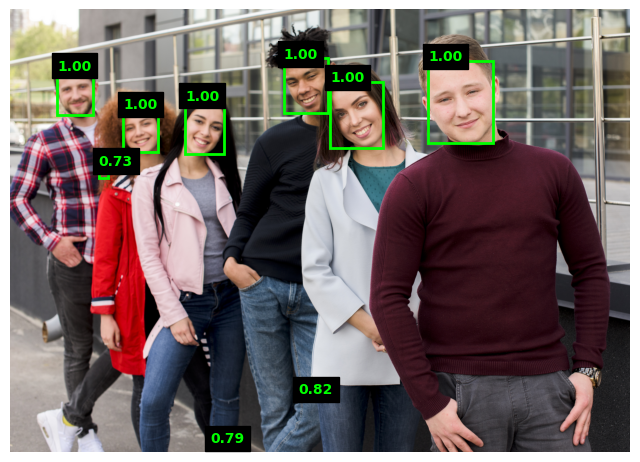

In [50]:
import matplotlib.patches as patches

boxes, probs = mtcnn.detect(test_image)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(test_image)

if boxes is not None:
    for box, prob in zip(boxes, probs):
        x1, y1, x2, y2 = box
        width, height = x2 - x1, y2 - y1

        rect = patches.Rectangle(
            (x1, y1), width, height,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)

        ax.text(
            x1, y1 - 5, f'{prob:.2f}',
            color='lime', fontsize=10, weight='bold',
            backgroundcolor='black'
        )

ax.axis('off')
plt.show()

Напишем отдельную функцию, которая вернёт нам bbox'ы (Возвращает две угловые точки)

In [51]:
def get_bboxs(img):
    boxes, probs = mtcnn.detect(img)
    sorted_boxes = []
    for box, prob in zip(boxes, probs):
      if prob > 0.9:
        sorted_boxes.append(box)
    return sorted_boxes

## Этап 2. Кроп лиц

Теперь берём предсказанные ббоксы и получаем из изображения кропнутые лица

In [52]:
def crop_faces(img, boxes):
    faces = []
    for box in boxes:
        x1, y1, x2, y2 = box
        face = img.crop((x1, y1, x2, y2))
        faces.append(face)
    return faces

Выведем полученные лица

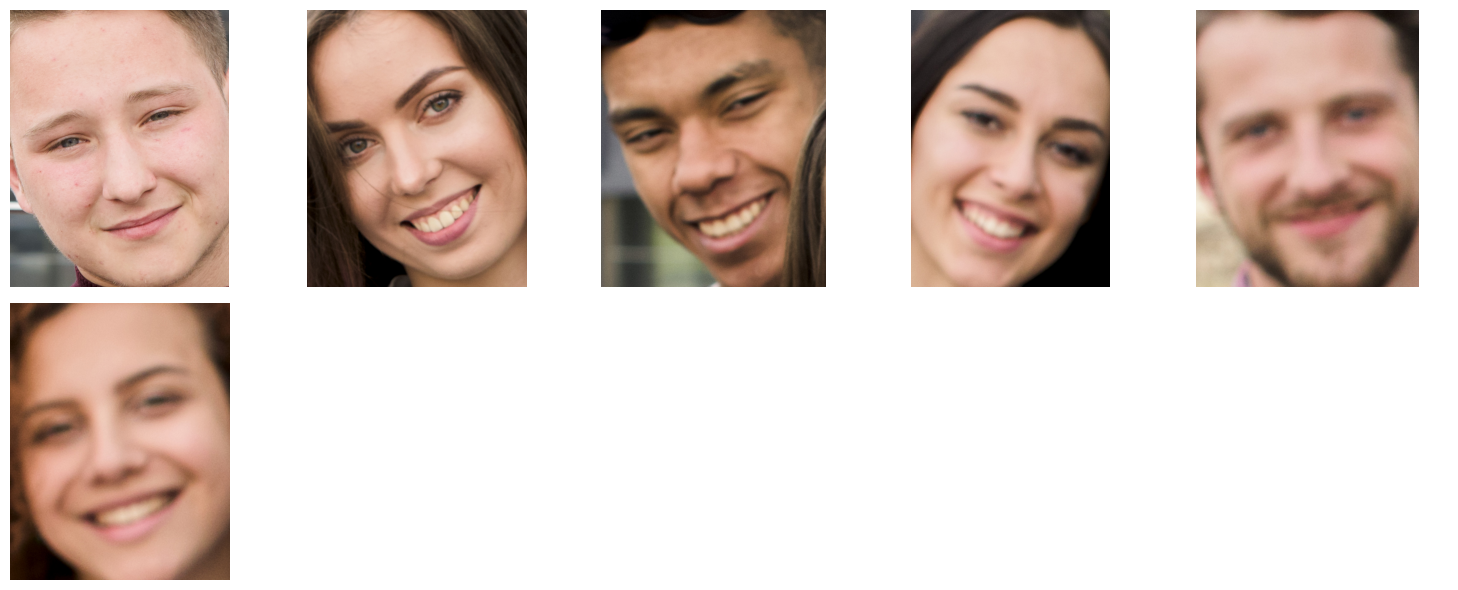

In [53]:
boxes = get_bboxs(test_image)
faces = crop_faces(test_image, boxes)

n = len(faces)
cols = min(n, 5)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = axes.flatten() if n > 1 else [axes]

for i, face in enumerate(faces):
    axes[i].imshow(face)
    axes[i].axis('off')

for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Этап 3. Предсказание лендмарков

Скопируем структуру нашей SHN модели из первого задания, подгрузим наши веса - затем предскажем точки лица. Не забываем что мы должны так же обработать наши кропнутые изображение перед подачей в модель

In [26]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(channels, channels // 2, 1),
            nn.BatchNorm2d(channels // 2),
            nn.ReLU(),

            nn.Conv2d(channels // 2, channels // 2, 3, padding=1),
            nn.BatchNorm2d(channels // 2),
            nn.ReLU(),

            nn.Conv2d(channels // 2, channels, 1),
            nn.BatchNorm2d(channels),
        )

        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.layers(x) + x)

class HourglassModule(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.skip = nn.Identity()
        self.layers = nn.ModuleList()
        factors = [1, 2, 4, 8, 16]

        # Блоки, за которыми следует Downsampling
        for i in range(4):
            self.layers.append(ResidualBlock(channels * factors[i]))
            self.layers.append(
                nn.Sequential(
                    nn.Conv2d(channels * factors[i], channels * factors[i+1], 3, stride=2, padding=1),
                    nn.BatchNorm2d(channels * factors[i+1]),
                )
            )

        # Bottleneck
        self.layers.append(
            nn.Sequential(
                ResidualBlock(channels * 16),
                ResidualBlock(channels * 16),
            )
        )

        factors = [16, 8, 4, 2, 1]
        # Блоки, за которыми следует Upsampling
        for i in range(4):
            self.layers.append(
                nn.Sequential(
                    ResidualBlock(channels * factors[i]),
                    nn.ConvTranspose2d(channels * factors[i], channels * factors[i+1], kernel_size=4, stride=2, padding=1),
                    nn.BatchNorm2d(channels * factors[i+1]),
                )
            )

        # Последний блок
        self.layers.append(ResidualBlock(channels))

        # "Большие" skip connections
        self.skip1 = ResidualBlock(channels)
        self.skip2 = ResidualBlock(channels*2)
        self.skip3 = ResidualBlock(channels*4)
        self.skip4 = ResidualBlock(channels*8)

    def forward(self, x):
        x = self.layers[0](x)
        res1 = self.skip1(x)

        x = self.layers[1](x)
        x = self.layers[2](x)
        res2 = self.skip2(x)

        x = self.layers[3](x)
        x = self.layers[4](x)
        res3 = self.skip3(x)

        x = self.layers[5](x)
        x = self.layers[6](x)
        res4 = self.skip4(x)

        x = self.layers[7](x)
        x = self.layers[8](x)

        x = self.layers[9](x)

        x = self.layers[10](x + res4)

        x = self.layers[11](x + res3)

        x = self.layers[12](x + res2)

        x = self.layers[13](x + res1)

        return x

class SHN(nn.Module):
    def __init__(self, in_channels=3, out_channels=5):
        super().__init__()

        self.prep = nn.Sequential(
                nn.Conv2d(in_channels, 16, 3, padding=1),
                nn.BatchNorm2d(16),
                nn.ReLU(),

                nn.Conv2d(16, out_channels, 3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
            )

        self.hourglasses = nn.ModuleList()

        for i in range(4):
            self.hourglasses.append(
                nn.Sequential(
                    nn.Conv2d(out_channels, 16, 1),
                    nn.BatchNorm2d(16),
                    nn.ReLU(),

                    HourglassModule(16),

                    nn.Conv2d(16, out_channels, 3, padding=1),
                    nn.BatchNorm2d(out_channels),
                    nn.ReLU(),
                    nn.Conv2d(out_channels, out_channels, 3, padding=1),
                )
            )

    def forward(self, x):
        heatmap1 = self.prep(x)
        heatmap2 = self.hourglasses[0](heatmap1) + heatmap1
        heatmap3 = self.hourglasses[1](heatmap2) + heatmap2
        heatmap4 = self.hourglasses[2](heatmap3) + heatmap3
        heatmap5 = self.hourglasses[3](heatmap4) + heatmap4
        return [heatmap1, heatmap2, heatmap3, heatmap4, heatmap5]

In [37]:
shn = SHN()
shn.load_state_dict(
    torch.load(
        '/content/drive/MyDrive/DLS Project Model Weights/best_SHN.pth',
        map_location=torch.device('cpu')
    )
)
shn.eval()
print('Success')

Success


In [38]:
def heatmaps_to_landmarks(heatmaps):
    landmarks = []
    for heatmap in heatmaps:
        sup = torch.argmax(heatmap)
        y = sup // heatmap.shape[1]
        x = sup % heatmap.shape[1]

        landmarks.append([x, y])
    return np.array(landmarks)

In [58]:
NORMALIZE_MEAN = [0.5, 0.5, 0.5]
NORMALIZE_STD = [0.5, 0.5, 0.5]

def prepare_imgs(imgs):
    transform = v2.Compose([
        v2.PILToTensor(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD),
        v2.Resize((256, 256)),
      ])

    prepared_imgs = []
    for img in imgs:
      prepared_img = transform(img)
      prepared_imgs.append(prepared_img)

    return torch.stack(prepared_imgs)

def get_landmarks(imgs):
  landmarks_arr = []
  with torch.no_grad():
    for img in imgs:
      heatmaps = shn(img.unsqueeze(0))[-1]
      heatmaps = heatmaps.squeeze(0)

      landmarks = heatmaps_to_landmarks(heatmaps)
      landmarks_arr.append(landmarks)

  return landmarks_arr


Проверяем работу функции - выведём лица с лендмарками на них

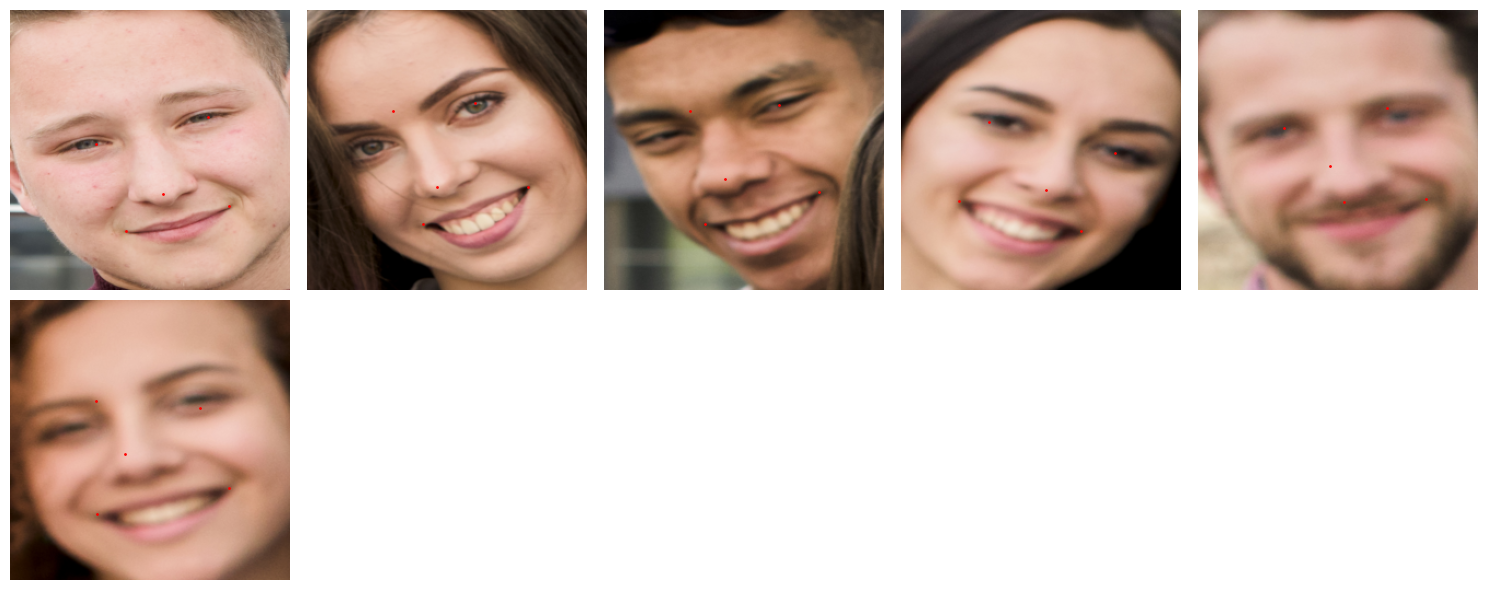

In [54]:
prepared_faces = prepare_imgs(faces)
landmarks = get_landmarks(prepared_faces)

n = len(faces)
cols = min(n, 5)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = axes.flatten() if n > 1 else [axes]

for i, face in enumerate(prepared_faces):
    face = face.permute(1, 2, 0).numpy()
    face = (face * 0.5 + 0.5).clip(0, 1)

    axes[i].imshow(face)
    for x, y in landmarks[i]:
        axes[i].scatter(x, y, c='red', s=1)
    axes[i].axis('off')

for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Этап 4. Выравнивание лиц

Теперь по предсказанным лендмаркам мы совершаем то же преоброзование, что мы делали в первом задание (Афииное с минимизацией MSE точек)

In [55]:
import cv2

size = [256, 256]
anchors = np.array([
    [0.3 * size[0], 0.3 * size[1]],
    [0.7 * size[0], 0.3 * size[1]],
    [0.5 * size[0], 0.5 * size[1]],
    [0.3 * size[0], 0.7 * size[1]],
    [0.7 * size[0], 0.7 * size[1]],
])

def align(imgs, landmarks):
  aligned_imgs = []
  for img, landmark in zip(imgs, landmarks):

    img = img.permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)
    img = (img * 255).astype(np.uint8)

    src = landmark.astype(np.float32)
    ref = anchors.astype(np.float32)

    M2, _ = cv2.estimateAffine2D(src, ref)
    aligned_img = cv2.warpAffine(img, M2, size, borderMode=cv2.BORDER_REPLICATE)

    aligned_imgs.append(aligned_img)

  return np.array(aligned_imgs)

И проверка как обработалось

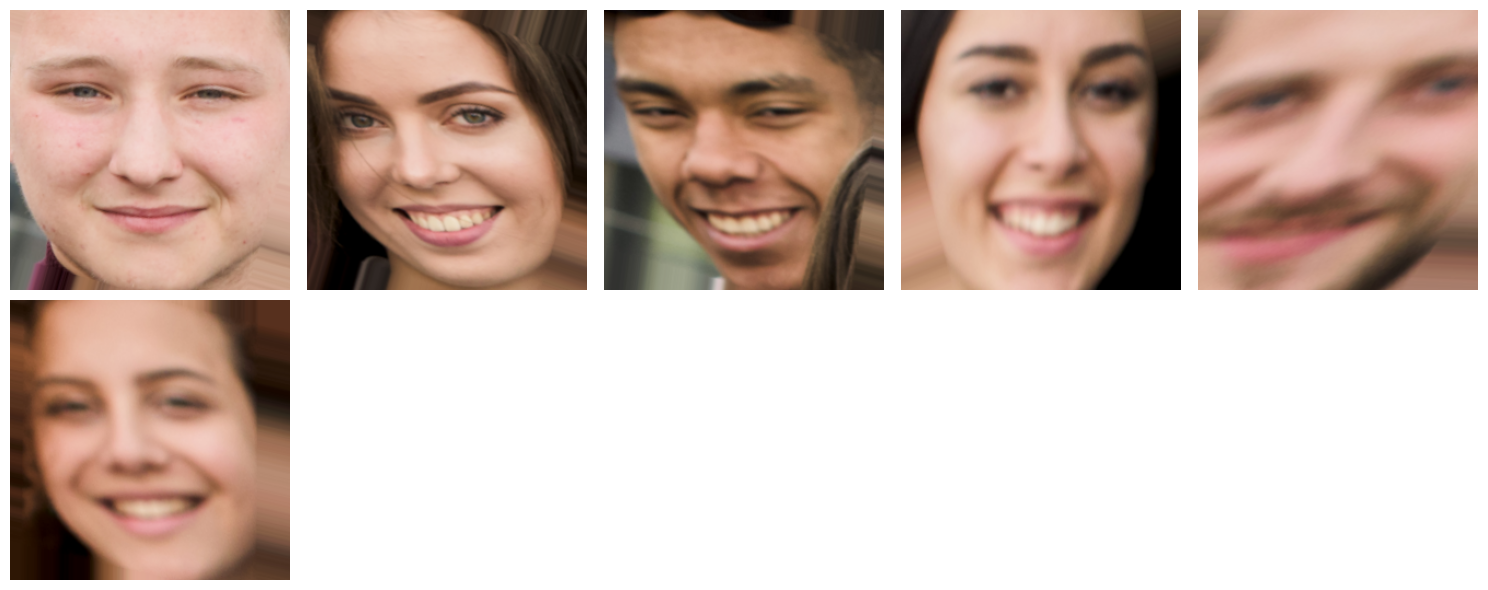

In [56]:
aligned_faces = align(prepared_faces, landmarks)

n = len(faces)
cols = min(n, 5)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = axes.flatten() if n > 1 else [axes]

for i, face in enumerate(aligned_faces):
    axes[i].imshow(face)
    axes[i].axis('off')

for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Этап 5. Получение эмбеддингов

Теперь подгрузим нашу модель из второго задания (Которая обучалась на ArcFace). Подготовим опять изображения, загоним в модель, получим эмбеддинги и выведем их.

Режим work соответствует обрезанному ArcFace

In [57]:
class ArcFace(nn.Module):
    def __init__(self, embedding_size, num_classes, s=64.0, m=0.5):
        super(ArcFace, self).__init__()
        self.s = s
        self.m = m

        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_size))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
      embeddings = F.normalize(embeddings, p=2, dim=1)
      weight_norm = F.normalize(self.weight, p=2, dim=1)

      cos_theta = F.linear(embeddings, weight_norm)
      cos_theta = cos_theta.clamp(-1.0 + 1e-7, 1.0 - 1e-7)
      sin_theta = torch.sqrt((1.0 - cos_theta ** 2).clamp(min=1e-7))

      cos_m, sin_m = np.cos(self.m), np.sin(self.m)
      th = np.cos(np.pi - self.m)
      mm = np.sin(np.pi - self.m) * self.m

      one_hot = torch.zeros_like(cos_theta)
      if labels is not None:
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1.0)

      target_logits = cos_theta * cos_m - sin_theta * sin_m
      target_logits = torch.where(cos_theta > th, target_logits, cos_theta - mm)

      output = cos_theta * (1 - one_hot) + target_logits * one_hot
      output *= self.s

      return output

class ArcFaceEN(nn.Module):
  def __init__(self, backbone, num_classes, embedding_size=1280, s=64.0, m=0.5):
    super().__init__()
    self.backbone = backbone
    self.dropout = nn.Dropout(p=0.2, inplace=True)
    self.classifier = ArcFace(embedding_size, num_classes, s, m)

  def forward(self, x, labels, mode='arcface'):
    '''
    mode = 'arcface': Use ArcFace, return logits
    mode = 'work': Skip ArcFace, return embeddings
    '''
    embeddings = self.backbone(x)
    if mode == 'arcface':
      embeddings = self.dropout(embeddings)
      logits = self.classifier(embeddings, labels)
      return logits
    elif mode == 'work':
      return F.normalize(embeddings, p=2, dim=1)

arcface_model = models.efficientnet_b0(weights='IMAGENET1K_V1')
arcface_model.classifier = nn.Identity()
arcface_model = ArcFaceEN(arcface_model, 794)
arcface_model.load_state_dict(
    torch.load(
        '/content/drive/MyDrive/DLS Project Model Weights/ArcFace_classifier.pth',
        map_location=torch.device('cpu')
    )
)
arcface_model.eval()
print('Success')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 118MB/s] 


Success


In [62]:
def prepare_imgs_2(imgs):
    transform = v2.Compose([
        v2.PILToTensor(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD),
        v2.Resize((224, 224)),
      ])

    prepared_imgs = []
    for img in imgs:
      prepared_img = Image.fromarray(img)
      prepared_img = transform(prepared_img)
      prepared_imgs.append(prepared_img)

    return torch.stack(prepared_imgs)

def get_embeddings(imgs):
  embeddings_arr = []
  with torch.no_grad():
    for img in imgs:
      embeddings = arcface_model(img.unsqueeze(0), None, mode='work')
      embeddings = embeddings.squeeze(0).numpy()
      embeddings_arr.append(embeddings)

  return embeddings_arr

In [63]:
embeddings = get_embeddings(prepare_imgs_2(aligned_faces))
embeddings

[array([ 0.01887912, -0.02422908, -0.0284449 , ...,  0.06548854,
         0.00246749, -0.01568138], dtype=float32),
 array([-0.02129087, -0.00206037,  0.01249684, ...,  0.00484559,
        -0.0302443 , -0.01868736], dtype=float32),
 array([ 0.01491125, -0.01503235, -0.01680978, ...,  0.05969227,
        -0.02092054, -0.0089504 ], dtype=float32),
 array([-0.01541397,  0.00805339, -0.00417546, ...,  0.0277563 ,
        -0.01899516,  0.02682635], dtype=float32),
 array([-0.00012138, -0.02356658, -0.00490942, ..., -0.02849491,
        -0.01677959, -0.01808139], dtype=float32),
 array([-0.0147834 ,  0.02934954, -0.01459499, ..., -0.02263976,
        -0.01027171, -0.0268901 ], dtype=float32)]

## Итоговая функция

Соеденим всё теперь в одну функцию, которая принимает на вход изображение, а на выход выдаёт эмбеддинги людей на фотографии

In [64]:
def img_to_embeddings(img):
  # Этап 1: Детекция лиц
  boxes = get_bboxs(img)

  # Этап 2: Кроп лиц
  croped_faces = crop_faces(img, boxes)

  # Этап 3: Предсказание лендмарков
  prepared_faces_1 = prepare_imgs(croped_faces)
  landmarks = get_landmarks(prepared_faces_1)

  # Этап 4: Выравнивание лиц
  aligned_faces = align(prepared_faces_1, landmarks)

  # Этап 5: Получение эмбеддингов
  prepared_faces_2 = prepare_imgs_2(aligned_faces)
  embeddings = get_embeddings(prepared_faces_2)

  return embeddings


In [65]:
embeddings = img_to_embeddings(test_image)
embeddings

[array([ 0.01887912, -0.02422908, -0.0284449 , ...,  0.06548854,
         0.00246749, -0.01568138], dtype=float32),
 array([-0.02129087, -0.00206037,  0.01249684, ...,  0.00484559,
        -0.0302443 , -0.01868736], dtype=float32),
 array([ 0.01491125, -0.01503235, -0.01680978, ...,  0.05969227,
        -0.02092054, -0.0089504 ], dtype=float32),
 array([-0.01541397,  0.00805339, -0.00417546, ...,  0.0277563 ,
        -0.01899516,  0.02682635], dtype=float32),
 array([-0.00012138, -0.02356658, -0.00490942, ..., -0.02849491,
        -0.01677959, -0.01808139], dtype=float32),
 array([-0.0147834 ,  0.02934954, -0.01459499, ..., -0.02263976,
        -0.01027171, -0.0268901 ], dtype=float32)]

# 3. Эксперемент

Теперь возьмём 3 фотографии. 2 с одинаковым лицом и 1 с другим - посмотрим на косинусные расстояния между ними. Мы хотим получить маленькое для одинаковых и большое для разных

Для эксперемента я взял 2 фотографии Леонардо Ди Каприо (по запросу в гугле) и 1 фотографию Анджелины Джоли (так же по запросу в гугле). Первые называются `same_1` и `same_2`, вторая `different`. Сначала выведем загруженные изображения

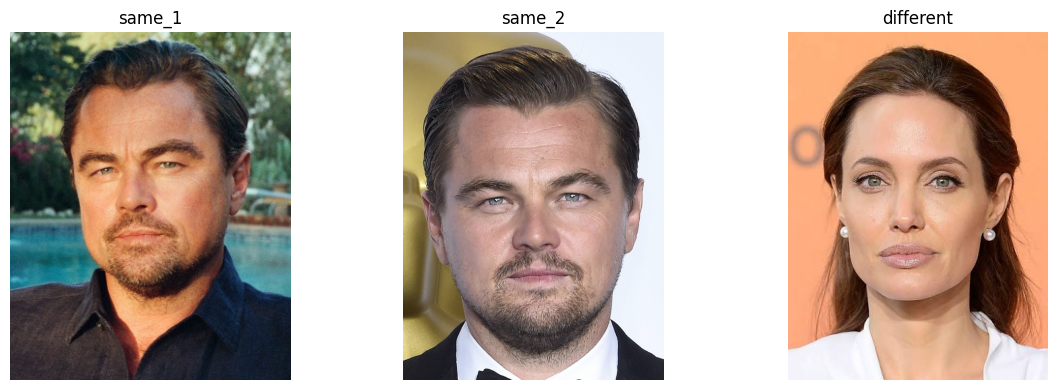

In [80]:
same_1 = Image.open('/content/same_1.jpg')
same_2 = Image.open('/content/same_2.jpg')
different = Image.open('/content/different.jpg')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(same_1)
axes[0].set_title('same_1')
axes[0].axis('off')

axes[1].imshow(same_2)
axes[1].set_title('same_2')
axes[1].axis('off')

axes[2].imshow(different)
axes[2].set_title('different')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Получаем эмбеддинги

In [81]:
same_1_embedding = torch.tensor(img_to_embeddings(same_1)[0])
same_2_embedding = torch.tensor(img_to_embeddings(same_2)[0])
different_embedding = torch.tensor(img_to_embeddings(different)[0])

print(same_1_embedding)
print(same_2_embedding)
print(different_embedding)

tensor([-0.0098, -0.0242,  0.0007,  ..., -0.0213,  0.0495, -0.0136])
tensor([-0.0241,  0.0065, -0.0071,  ..., -0.0172, -0.0007, -0.0020])
tensor([-0.0029, -0.0156, -0.0294,  ..., -0.0210,  0.0223, -0.0190])


Считаем косинусные сходства

In [82]:
embeddings = torch.stack([same_1_embedding, same_2_embedding, different_embedding])

cos_matrix = F.cosine_similarity(embeddings.unsqueeze(1), embeddings.unsqueeze(0), dim=2)
print(cos_matrix)

tensor([[ 1.0000,  0.0725, -0.0358],
        [ 0.0725,  1.0000, -0.0550],
        [-0.0358, -0.0550,  1.0000]])


Отлично! Получили косинусное сходство у одинаковых фотографий больше, чем у разных. Однако оно все равно мало. Проблемой может служить наше недоброкачественное обучение ArcFace модели

# 4. Выводы по обязательной части

Итак, этот ноутбук завершает обязательную часть проекта. Можем сказать следующее:

1. С обучением SHN проблем не возникло вообще. Здесь нашая большая вариативность датасета сыграла лишь наруку, т.к. у модели не было возможности учить положение лендмарков основываясь на том, что за человек на фотографии. Афинное преоброзование с минимизацией MSE работает очень хорошо. Могу сказать что эта часть задания полностью успешна

2. Как и было уже описано в предыдущем ноутбуке - у нас переобучение. Причины так же описаны в выводах предыдущего ноутбука. Конечно, мы получили достаточное качество классификации - но назвать обученную модель качественной сложно

3. Ну и как следствие пункта 2 - наши эмбеддинги не то чтобы хорошо распределяются по сфере. В целом мы получили нашу модель и если вернуть ArcFace слой, то мы навернека получим хорошую классификацию на людях из датасета - однако хотелось бы хорошо именно различать людей, а не классифицировать, чтобы модель была применима на произвольных людях